# 5. Squat Feature Extraction (Google Colab)

This notebook starts after YOLO pose extraction is complete.

Input:
- `pose_feature_index_squat.csv`
- YOLO pose feature `.npy` files with shape `[T, 51]`

Output:
- processed squat feature `.npy` files
- a feature index CSV
- a processing summary CSV

## Reason, Approach, Idea, Result Interpretation

**Reason for this section**
- Raw YOLO pose arrays are too noisy to use directly for rep counting.
- We need stable squat-specific features instead of raw keypoints.

**Approach**
- Reshape pose arrays from `[T, 51]` to `[T, 17, 3]`.
- Apply confidence filtering, gap filling, smoothing, and normalization.
- Derive biomechanical signals such as knee angle, knee flex, hip drop, and hip velocity.

**Core idea**
- Rep counting should work on cleaner motion signals, not directly on raw detector output.
- This stage turns pose into interpretable squat features.

**How to interpret results**
- `status = ok` means a pose file was converted into engineered squat features.
- `frames_valid` is now a weighted lower-body support score summed across frames, not a strict binary frame count.
- `mean_conf` is now lower-body confidence aligned to squat counting, not a whole-body keypoint average.
- If many videos fail here, the problem is usually path setup, unreadable pose files, or extreme upstream pose failure.


## 0. Connect Google Drive

**Why this section exists**
This notebook reads squat pose features from Drive and writes the processed squat features back to Drive, so the Drive mount must exist before any path setup.

**Approach / idea**
Mount Google Drive once at the start of the runtime so all later path definitions point to a persistent storage location instead of temporary `/content` storage.

**Result interpretation**
If Drive mounts successfully here, the path cells that follow should resolve to real files and directories under `/content/drive`.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 1. Paths and Runtime

Use this notebook after the squat-only YOLO extraction notebook has already produced pose features.

**Why this section exists**
This notebook depends on the pose outputs from step 4 and needs stable Drive-based paths so the extracted `.npy` files persist across sessions.

**Approach / idea**
Define all input and output roots up front and keep the runtime assumptions explicit before loading any data.

**Result interpretation**
If these paths are correct, downstream failures are more likely to be feature logic issues than missing-file issues.


In [2]:
from pathlib import Path

CODE_ROOT = Path('/content/CV_Image_pose_detection')
DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection')
ANNOTATION_DIR = DRIVE_PROJECT_ROOT / 'Data' / 'LLSP' / 'annotation_cleaned'
POSE_INDEX_CSV = ANNOTATION_DIR / 'pose_feature_index_squat.csv'
POSE_FEATURE_DIR = ANNOTATION_DIR / 'pose_features'

OUTPUT_DIR = ANNOTATION_DIR / 'squat_features'
OUTPUT_INDEX_CSV = ANNOTATION_DIR / 'squat_feature_index.csv'
OUTPUT_SUMMARY_CSV = ANNOTATION_DIR / 'squat_feature_summary.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('CODE_ROOT =', CODE_ROOT)
print('DRIVE_PROJECT_ROOT =', DRIVE_PROJECT_ROOT)
print('POSE_INDEX_CSV =', POSE_INDEX_CSV)
print('POSE_FEATURE_DIR =', POSE_FEATURE_DIR)
print('OUTPUT_DIR =', OUTPUT_DIR)

CODE_ROOT = /content/CV_Image_pose_detection
DRIVE_PROJECT_ROOT = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection
POSE_INDEX_CSV = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/pose_feature_index_squat.csv
POSE_FEATURE_DIR = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/pose_features
OUTPUT_DIR = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_features


## 2. Imports

**Why this section exists**
Feature engineering uses numerical processing, tabular summaries, and plotting utilities that should be loaded once near the top.

**Approach / idea**
Import the notebook dependencies in one place so later cells can focus on the pipeline logic itself.

**Result interpretation**
Import failures here usually indicate an environment problem rather than a dataset or model problem.


In [3]:
import csv
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load Squat Pose Index

**Why this section exists**
The pose index is the contract between step 4 and step 5 and tells the notebook which extracted pose files should exist.

**Approach / idea**
Load the squat pose index, normalize any environment-specific paths, and verify that the referenced files are reachable in Colab.

**Result interpretation**
A clean file-existence check here means the notebook can move on to feature logic; failures here should be fixed before batch processing.


In [4]:
pose_index = pd.read_csv(POSE_INDEX_CSV)

LOCAL_ROOT = '/Users/lindaperez/Documents/COMPUTER_VISION/Final_project/personal-git/'
CONTENT_ROOT = '/content/CV_Image_pose_detection/'
DRIVE_ROOT = '/content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/'

def normalize_feature_path(path_str: str) -> str:
    p = str(path_str)
    if p.startswith(LOCAL_ROOT):
        return p.replace(LOCAL_ROOT, DRIVE_ROOT)
    if p.startswith(CONTENT_ROOT):
        return p.replace(CONTENT_ROOT, DRIVE_ROOT)
    return p

pose_index['feature_path'] = pose_index['feature_path'].astype(str).apply(normalize_feature_path)

pose_index.head()

,name,feature_path,type,split,count
0,test2340.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,4.0
1,stu4_66.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,27.0
2,stu9_63.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0
3,stu1_68.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0
4,stu6_62.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,squat,train,20.0


In [5]:
print('rows =', len(pose_index))
print('missing pose files =', int((~pose_index['feature_path'].map(lambda p: Path(p).exists())).sum()))

rows = 118
missing pose files = 0


## 4. COCO Keypoint Layout

YOLO pose uses 17 COCO keypoints.

**Why this section exists**
The extracted pose arrays are numeric only, so the notebook needs a fixed keypoint ordering to interpret hips, knees, ankles, and other joints correctly.

**Approach / idea**
Declare the 17-keypoint COCO layout once and reuse it consistently when reshaping `[T, 51]` pose arrays.

**Result interpretation**
If the layout is wrong, every downstream angle and motion feature will be wrong even though the code still runs.


In [6]:
KEYPOINT_NAMES = [
    'nose',
    'left_eye', 'right_eye',
    'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
]

KPT = {name: idx for idx, name in enumerate(KEYPOINT_NAMES)}
KPT

{'nose': 0,
 'left_eye': 1,
 'right_eye': 2,
 'left_ear': 3,
 'right_ear': 4,
 'left_shoulder': 5,
 'right_shoulder': 6,
 'left_elbow': 7,
 'right_elbow': 8,
 'left_wrist': 9,
 'right_wrist': 10,
 'left_hip': 11,
 'right_hip': 12,
 'left_knee': 13,
 'right_knee': 14,
 'left_ankle': 15,
 'right_ankle': 16}

## 5. Helper Functions

**Why this section exists**
Preprocessing and feature extraction involve repeated operations such as reshaping, smoothing, normalization, and angle computation.

**Approach / idea**
Centralize that logic into helper functions so batch processing and single-video inspection use the same transformations.

**Result interpretation**
This section defines the actual feature pipeline; if later results look unstable, these helpers are the first place to inspect.


In [7]:
CONF_THRESHOLD = 0.25
EMA_ALPHA = 0.2
MIN_SCALE = 1e-6
LOWER_BODY_WEIGHT_MAP = {
    'left_hip': 2.0,
    'right_hip': 2.0,
    'left_knee': 2.0,
    'right_knee': 2.0,
    'left_ankle': 1.0,
    'right_ankle': 1.0,
}
HIP_KNEE_WEIGHT_MAP = {
    'left_hip': 1.0,
    'right_hip': 1.0,
    'left_knee': 1.0,
    'right_knee': 1.0,
}
LOWER_BODY_NAMES = list(LOWER_BODY_WEIGHT_MAP.keys())
HIP_KNEE_NAMES = list(HIP_KNEE_WEIGHT_MAP.keys())


def keypoint_weights(weight_map: dict[str, float]) -> np.ndarray:
    return np.array([weight_map[name] for name in weight_map], dtype=np.float32)


LOWER_BODY_WEIGHTS = keypoint_weights(LOWER_BODY_WEIGHT_MAP)
HIP_KNEE_WEIGHTS = keypoint_weights(HIP_KNEE_WEIGHT_MAP)
LOWER_BODY_IDX = np.array([KPT[name] for name in LOWER_BODY_NAMES], dtype=np.int32)
HIP_KNEE_IDX = np.array([KPT[name] for name in HIP_KNEE_NAMES], dtype=np.int32)


def load_pose_array(path: Path) -> np.ndarray:
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] != 51:
        raise ValueError(f'Expected [T, 51], got {arr.shape} for {path}')
    return arr.astype(np.float32)


def reshape_pose(arr: np.ndarray) -> np.ndarray:
    return arr.reshape(arr.shape[0], 17, 3)


def forward_fill_nan(xy: np.ndarray) -> np.ndarray:
    out = xy.copy()
    for t in range(1, out.shape[0]):
        missing = np.isnan(out[t])
        out[t][missing] = out[t - 1][missing]
    return out


def backward_fill_nan(xy: np.ndarray) -> np.ndarray:
    out = xy.copy()
    for t in range(out.shape[0] - 2, -1, -1):
        missing = np.isnan(out[t])
        out[t][missing] = out[t + 1][missing]
    return out


def ema_smooth(xy: np.ndarray, alpha: float = EMA_ALPHA) -> np.ndarray:
    out = xy.copy()
    for t in range(1, out.shape[0]):
        out[t] = alpha * out[t] + (1.0 - alpha) * out[t - 1]
    return out


def preprocess_pose(pose: np.ndarray, conf_threshold: float = CONF_THRESHOLD, alpha: float = EMA_ALPHA):
    xy = pose[:, :, :2].copy()
    conf = pose[:, :, 2].copy()

    xy[conf < conf_threshold] = np.nan
    valid_mask = conf >= conf_threshold

    xy = forward_fill_nan(xy)
    xy = backward_fill_nan(xy)
    xy = np.nan_to_num(xy, nan=0.0)
    xy = ema_smooth(xy, alpha=alpha)
    return xy, conf, valid_mask


def midpoint(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return (a + b) / 2.0


def vector_angle(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> np.ndarray:
    ba = a - b
    bc = c - b
    dot = np.sum(ba * bc, axis=-1)
    norm_ba = np.linalg.norm(ba, axis=-1)
    norm_bc = np.linalg.norm(bc, axis=-1)
    denom = np.clip(norm_ba * norm_bc, 1e-6, None)
    cosine = np.clip(dot / denom, -1.0, 1.0)
    return np.degrees(np.arccos(cosine))


def normalize_pose(xy: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    left_hip = xy[:, KPT['left_hip']]
    right_hip = xy[:, KPT['right_hip']]
    left_shoulder = xy[:, KPT['left_shoulder']]
    right_shoulder = xy[:, KPT['right_shoulder']]

    hip_center = midpoint(left_hip, right_hip)
    shoulder_center = midpoint(left_shoulder, right_shoulder)
    scale = np.linalg.norm(shoulder_center - hip_center, axis=-1)
    scale = np.clip(scale, MIN_SCALE, None)

    normalized = (xy - hip_center[:, None, :]) / scale[:, None, None]
    return normalized, hip_center, scale


def weighted_average(values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    weights = weights.astype(np.float32)
    denom = np.clip(weights.sum(), 1e-6, None)
    return (values * weights[None, :]).sum(axis=1) / denom


def build_frame_features(normalized_xy: np.ndarray, conf: np.ndarray, valid_mask: np.ndarray) -> pd.DataFrame:
    left_knee_angle = vector_angle(
        normalized_xy[:, KPT['left_hip']],
        normalized_xy[:, KPT['left_knee']],
        normalized_xy[:, KPT['left_ankle']],
    )
    right_knee_angle = vector_angle(
        normalized_xy[:, KPT['right_hip']],
        normalized_xy[:, KPT['right_knee']],
        normalized_xy[:, KPT['right_ankle']],
    )

    left_hip_angle = vector_angle(
        normalized_xy[:, KPT['left_shoulder']],
        normalized_xy[:, KPT['left_hip']],
        normalized_xy[:, KPT['left_knee']],
    )
    right_hip_angle = vector_angle(
        normalized_xy[:, KPT['right_shoulder']],
        normalized_xy[:, KPT['right_hip']],
        normalized_xy[:, KPT['right_knee']],
    )

    hip_center_y = midpoint(normalized_xy[:, KPT['left_hip']], normalized_xy[:, KPT['right_hip']])[:, 1]
    knee_center_y = midpoint(normalized_xy[:, KPT['left_knee']], normalized_xy[:, KPT['right_knee']])[:, 1]
    ankle_center_y = midpoint(normalized_xy[:, KPT['left_ankle']], normalized_xy[:, KPT['right_ankle']])[:, 1]

    lower_body_conf = weighted_average(conf[:, LOWER_BODY_IDX], LOWER_BODY_WEIGHTS)
    hip_knee_conf = weighted_average(conf[:, HIP_KNEE_IDX], HIP_KNEE_WEIGHTS)
    lower_body_valid_score = weighted_average(valid_mask[:, LOWER_BODY_IDX].astype(np.float32), LOWER_BODY_WEIGHTS)
    hip_knee_valid_score = weighted_average(valid_mask[:, HIP_KNEE_IDX].astype(np.float32), HIP_KNEE_WEIGHTS)

    avg_knee_angle = (left_knee_angle + right_knee_angle) / 2.0
    avg_hip_angle = (left_hip_angle + right_hip_angle) / 2.0
    knee_flex = 180.0 - avg_knee_angle
    hip_drop = knee_center_y - hip_center_y
    leg_extension = ankle_center_y - hip_center_y
    hip_velocity = np.gradient(hip_center_y)
    frame_valid = np.where(
        hip_knee_valid_score >= 0.5,
        np.maximum(lower_body_valid_score, hip_knee_valid_score),
        0.0,
    ).astype(np.float32)

    return pd.DataFrame({
        'frame_idx': np.arange(len(normalized_xy), dtype=np.int32),
        'left_knee_angle': left_knee_angle,
        'right_knee_angle': right_knee_angle,
        'avg_knee_angle': avg_knee_angle,
        'knee_flex': knee_flex,
        'left_hip_angle': left_hip_angle,
        'right_hip_angle': right_hip_angle,
        'avg_hip_angle': avg_hip_angle,
        'hip_center_y': hip_center_y,
        'knee_center_y': knee_center_y,
        'ankle_center_y': ankle_center_y,
        'hip_drop': hip_drop,
        'leg_extension': leg_extension,
        'hip_velocity': hip_velocity,
        'frame_valid': frame_valid,
        'mean_conf': lower_body_conf,
    })


## 6. Inspect One Pose File

**Why this section exists**
A single-video inspection confirms that the helpers behave sensibly before the notebook processes the full squat set.

**Approach / idea**
Load one extracted pose file, run the feature pipeline, and visually inspect the intermediate outputs and derived signals.

**Result interpretation**
If one example already looks broken here, batch results will only scale up the same bug.


In [8]:
sample_row = pose_index.iloc[0]
sample_pose_path = Path(sample_row['feature_path'])
sample_arr = load_pose_array(sample_pose_path)
sample_pose = reshape_pose(sample_arr)
sample_xy, sample_conf, sample_valid = preprocess_pose(sample_pose)
sample_norm_xy, sample_hip_center, sample_scale = normalize_pose(sample_xy)
sample_features = build_frame_features(sample_norm_xy, sample_conf, sample_valid)

print('video =', sample_row['name'])
print('raw pose shape =', sample_arr.shape)
print('processed feature shape =', sample_features.shape)
sample_features.head()

video = test2340.mp4
raw pose shape = (300, 51)
processed feature shape = (300, 16)


,frame_idx,left_knee_angle,right_knee_angle,avg_knee_angle,knee_flex,left_hip_angle,right_hip_angle,avg_hip_angle,hip_center_y,knee_center_y,ankle_center_y,hip_drop,leg_extension,hip_velocity,frame_valid,mean_conf
0,0,86.352844,90.348091,88.350464,91.649536,70.691925,84.789009,77.740463,0.000000e+00,0.755505,2.076810,0.755505,2.076810,4.377216e-08,1.0,0.968391
1,1,87.833275,90.829323,89.331299,90.668701,69.988403,84.587166,77.287781,4.377216e-08,0.750300,2.077808,0.750300,2.077808,0.000000e+00,1.0,0.990984
2,2,88.312500,90.441620,89.377060,90.622940,67.750572,82.363701,75.057137,0.000000e+00,0.716673,2.003230,0.716673,2.003230,-4.214235e-08,1.0,0.990503
3,3,88.429710,89.347824,88.888763,91.111237,65.941605,79.731735,72.836670,-4.051253e-08,0.668541,1.890939,0.668541,1.890939,0.000000e+00,1.0,0.991104
4,4,87.974617,87.171066,87.572845,92.427155,63.374439,76.536415,69.955429,0.000000e+00,0.619662,1.790800,0.619662,1.790800,2.025627e-08,1.0,0.987003


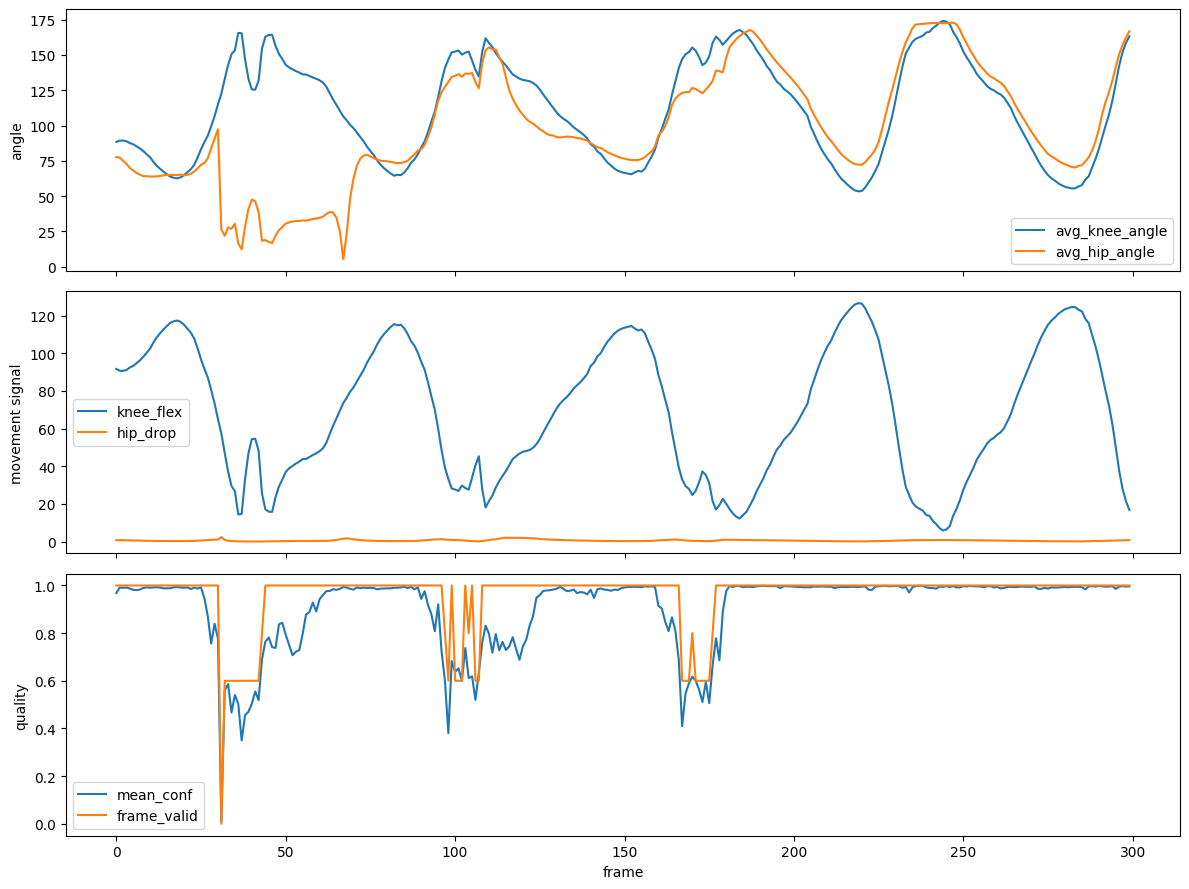

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(sample_features['avg_knee_angle'], label='avg_knee_angle')
axes[0].plot(sample_features['avg_hip_angle'], label='avg_hip_angle')
axes[0].legend()
axes[0].set_ylabel('angle')

axes[1].plot(sample_features['knee_flex'], label='knee_flex')
axes[1].plot(sample_features['hip_drop'], label='hip_drop')
axes[1].legend()
axes[1].set_ylabel('movement signal')

axes[2].plot(sample_features['mean_conf'], label='mean_conf')
axes[2].plot(sample_features['frame_valid'], label='frame_valid')
axes[2].legend()
axes[2].set_ylabel('quality')
axes[2].set_xlabel('frame')

plt.tight_layout()
plt.show()

## 7. Batch Feature Extraction

**Why this section exists**
This is the step that transforms all squat pose sequences into downstream-ready squat feature files.

**Approach / idea**
Loop through the squat index, apply the same preprocessing and feature logic to each pose file, and save the results with summary metadata.

**Result interpretation**
The status counts here show whether step 5 finished cleanly and whether any videos still need investigation.


In [10]:
@dataclass
class FeatureRunResult:
    name: str
    pose_path: str
    feature_path: str
    status: str
    frames_total: int
    frames_valid: int
    mean_conf: float
    message: str


def process_one_pose_file(row: pd.Series) -> tuple[pd.DataFrame, FeatureRunResult]:
    name = row['name']
    pose_path = Path(row['feature_path'])
    output_path = OUTPUT_DIR / f"{pose_path.stem}_squat_features.npy"

    try:
        arr = load_pose_array(pose_path)
        pose = reshape_pose(arr)
        xy, conf, valid = preprocess_pose(pose)
        normalized_xy, hip_center, scale = normalize_pose(xy)
        features = build_frame_features(normalized_xy, conf, valid)
        np.save(output_path, features.to_numpy(dtype=np.float32))
        result = FeatureRunResult(
            name=name,
            pose_path=str(pose_path),
            feature_path=str(output_path),
            status='ok',
            frames_total=int(len(features)),
            frames_valid=int(features['frame_valid'].sum()),
            mean_conf=float(features['mean_conf'].mean()),
            message='',
        )
        return features, result
    except Exception as exc:
        result = FeatureRunResult(
            name=name,
            pose_path=str(pose_path),
            feature_path=str(output_path),
            status='failed',
            frames_total=0,
            frames_valid=0,
            mean_conf=0.0,
            message=str(exc),
        )
        return pd.DataFrame(), result

In [11]:
results = []
feature_index_rows = []

for i, row in pose_index.iterrows():
    features, result = process_one_pose_file(row)
    results.append(result.__dict__)
    if result.status == 'ok':
        feature_index_rows.append({
            'name': result.name,
            'pose_path': result.pose_path,
            'feature_path': result.feature_path,
            'type': row.get('type', 'squat'),
            'split': row.get('split', ''),
            'count': row.get('count', ''),
        })
    if (i + 1) % 25 == 0 or (i + 1) == len(pose_index):
        print(f'[{i + 1}/{len(pose_index)}] processed')

[25/118] processed
[50/118] processed
[75/118] processed
[100/118] processed
[118/118] processed


In [12]:
summary_df = pd.DataFrame(results)
feature_index_df = pd.DataFrame(feature_index_rows)

summary_df.to_csv(OUTPUT_SUMMARY_CSV, index=False)
feature_index_df.to_csv(OUTPUT_INDEX_CSV, index=False)

print('saved summary =', OUTPUT_SUMMARY_CSV)
print('saved feature index =', OUTPUT_INDEX_CSV)
summary_df.head()

saved summary = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_summary.csv
saved feature index = /content/drive/MyDrive/FinalProjectCV/CV_Image_pose_detection/Data/LLSP/annotation_cleaned/squat_feature_index.csv


,name,pose_path,feature_path,status,frames_total,frames_valid,mean_conf,message
0,test2340.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,300,288,0.906618,
1,stu4_66.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,1125,1021,0.858571,
2,stu9_63.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,1350,1331,0.975102,
3,stu1_68.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,936,936,0.994568,
4,stu6_62.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,749,748,0.986690,


## 8. Run Summary

**Why this section exists**
The batch summary provides a quick quality check over the full squat subset without opening each generated file manually.

**Approach / idea**
Aggregate the run-level status and a few quality indicators such as weighted lower-body support and lower-body confidence.

**Result interpretation**
Use these numbers to decide whether the feature set is healthy enough for rep counting or whether preprocessing needs revision first.


In [13]:
print(summary_df['status'].value_counts(dropna=False))
print('\nmean weighted valid support =', summary_df.loc[summary_df['status'] == 'ok', 'frames_valid'].mean())
print('mean lower-body confidence =', summary_df.loc[summary_df['status'] == 'ok', 'mean_conf'].mean())

status
ok    118
Name: count, dtype: int64

mean weighted valid support = 872.042372881356
mean lower-body confidence = 0.9408578704726898


What we can conclude from those numbers:

status = ok for all 118 rows means every squat pose file was converted into engineered squat features successfully.
mean weighted valid support = 872.04 means that, on average, each video has a large amount of usable lower-body signal for downstream counting.
mean lower-body confidence = 0.9409 is very high, which suggests the extracted squat features are based on strong pose detections rather than weak or noisy lower-body keypoints.


In [14]:
summary_df.sort_values(['status', 'frames_valid', 'mean_conf']).head(10)

,name,pose_path,feature_path,status,frames_total,frames_valid,mean_conf,message
114,train3898.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,299,77,0.232047,
81,test2295.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,100,100,0.992036,
88,stu1_70.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,120,120,0.979735,
115,test2349.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,128,128,0.963210,
29,test2319.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,232,140,0.405426,
27,stu3_59.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,180,180,0.860216,
15,train3948.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,204,204,0.888131,
63,stu3_60.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,210,210,0.993653,
86,test2323.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,256,227,0.812808,
5,stu8_64.mp4,/content/drive/MyDrive/FinalProjectCV/CV_Image...,/content/drive/MyDrive/FinalProjectCV/CV_Image...,ok,250,245,0.859878,


## 9. Output Contract for the Next Step

The next notebook can now consume:

- `squat_feature_index.csv`
- `squat_features/*.npy`

That next stage should focus on:
- choosing the best rep-count signal
- defining state transitions
- building a squat FSM counter

**Why this section exists**
Step 6 depends on a stable feature schema and file layout, so this section makes the handoff explicit.

**Approach / idea**
Document what each saved feature file contains and which index/summary files the rep-count notebook should read.

**Result interpretation**
If this contract is clear and stable, step 6 can evolve independently without reopening the pose-extraction logic.
